In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
# Load data
X_val  = pd.read_csv('../data/processed/X_val.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_val  = pd.read_csv('../data/processed/y_val.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Load models
rf_model  = joblib.load('../models/random_forest.pkl')
svm_model = joblib.load('../models/svm_model.pkl')
dnn_model = tf.keras.models.load_model('../models/dnn_model.keras')

print("✅ All models loaded!")

✅ All models loaded!


C:\Users\Malik Taha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 14 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred)*100, 2),
        'Precision': round(precision_score(y_true, y_pred)*100, 2),
        'Recall':    round(recall_score(y_true, y_pred)*100, 2),
        'F1-Score':  round(f1_score(y_true, y_pred)*100, 2),
        'AUC-ROC':   round(roc_auc_score(y_true, y_prob)*100, 2),
    }

results = []

# Random Forest
rf_pred  = rf_model.predict(X_val)
rf_prob  = rf_model.predict_proba(X_val)[:, 1]
results.append(evaluate_model('Random Forest', y_val, rf_pred, rf_prob))

# SVM
svm_pred = svm_model.predict(X_val)
svm_prob = svm_model.predict_proba(X_val)[:, 1]
results.append(evaluate_model('SVM', y_val, svm_pred, svm_prob))

# DNN
dnn_prob = dnn_model.predict(X_val).ravel()
dnn_pred = (dnn_prob > 0.5).astype(int)
results.append(evaluate_model('DNN', y_val, dnn_pred, dnn_prob))

# Show comparison table
df_results = pd.DataFrame(results).set_index('Model')
print(df_results.to_string())

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


842/842 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                        
Random Forest     99.92      99.95   99.89     99.92   100.00
SVM               96.09      98.68   93.44     95.99    99.16
DNN               99.51      99.63   99.39     99.51    99.98


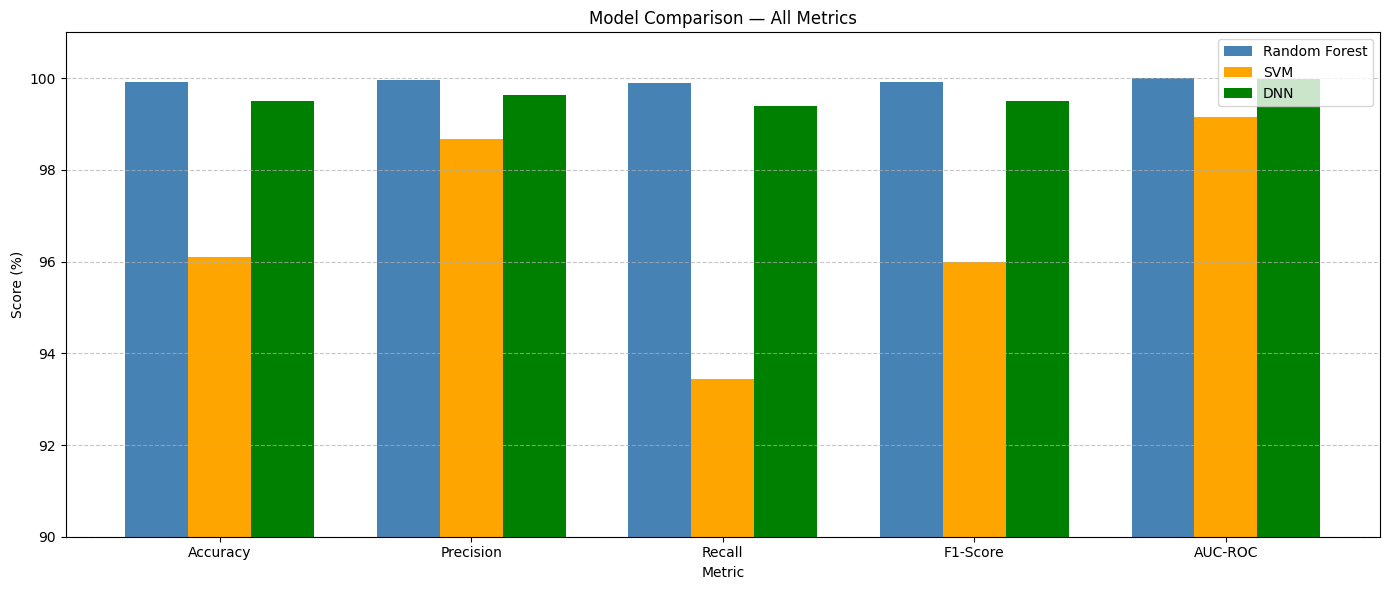

In [4]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x       = np.arange(len(metrics))
width   = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - width, df_results.loc['Random Forest', metrics], width, label='Random Forest', color='steelblue')
ax.bar(x,         df_results.loc['SVM',           metrics], width, label='SVM',           color='orange')
ax.bar(x + width, df_results.loc['DNN',           metrics], width, label='DNN',           color='green')

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim([90, 101])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../docs/model_comparison.png')
plt.show()

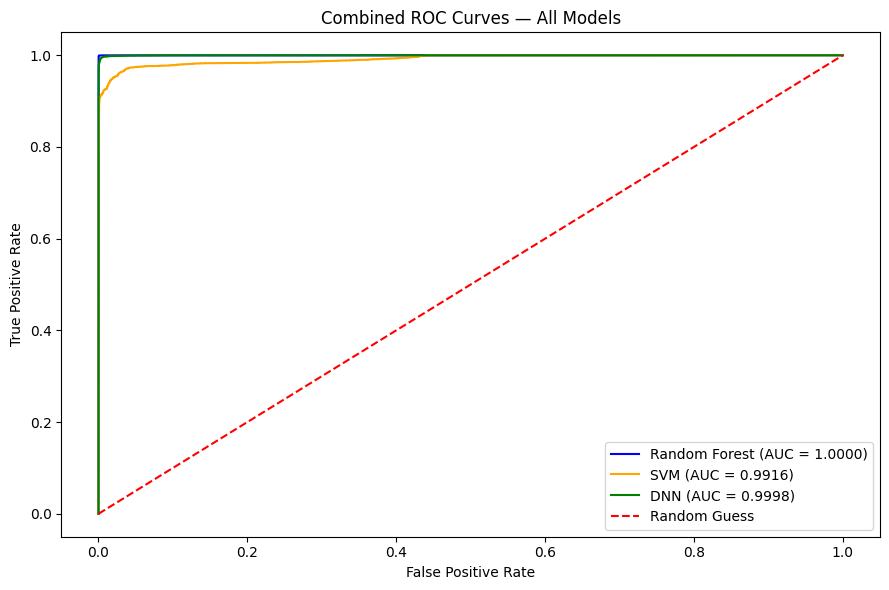

In [5]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 6))

for name, prob, color in [
    ('Random Forest', rf_prob,  'blue'),
    ('SVM',           svm_prob, 'orange'),
    ('DNN',           dnn_prob, 'green')
]:
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc         = roc_auc_score(y_val, prob)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0,1], [0,1], 'r--', label='Random Guess')
plt.title('Combined ROC Curves — All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/combined_roc_curves.png')
plt.show()

In [7]:
# Combine train + validation for final model
import numpy as np

X_train_orig = pd.read_csv('../data/processed/X_train_final.csv')
X_val_orig   = pd.read_csv('../data/processed/X_val.csv')
y_train_orig = pd.read_csv('../data/processed/y_train_final.csv').values.ravel()
y_val_orig   = pd.read_csv('../data/processed/y_val.csv').values.ravel()

X_combined = np.vstack([X_train_orig, X_val_orig])
y_combined = np.concatenate([y_train_orig, y_val_orig])

print("⏳ Retraining on full data...")

from sklearn.ensemble import RandomForestClassifier
best_model_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

best_model_v2.fit(X_combined, y_combined)

# Evaluate on test set
test_pred = best_model_v2.predict(X_test)
test_prob = best_model_v2.predict_proba(X_test)[:, 1]

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

print("\n" + "=" * 45)
print("   FINAL TEST SET RESULTS (Retrained)")
print("=" * 45)
print(f"Test Accuracy:  {accuracy_score(y_test, test_pred)*100:.2f}%")
print(f"Test Precision: {precision_score(y_test, test_pred)*100:.2f}%")
print(f"Test Recall:    {recall_score(y_test, test_pred)*100:.2f}%")
print(f"Test F1-Score:  {f1_score(y_test, test_pred)*100:.2f}%")
print(f"Test AUC-ROC:   {roc_auc_score(y_test, test_prob)*100:.2f}%")
print("=" * 45)

# Save improved model
joblib.dump(best_model_v2, '../models/best_model.pkl')
print("\n✅ Improved model saved!")

⏳ Retraining on full data...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    9.0s finished
C:\Users\Malik Taha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished
C:\Users\Malik Taha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
[Paral


   FINAL TEST SET RESULTS (Retrained)
Test Accuracy:  77.31%
Test Precision: 96.72%
Test Recall:    62.25%
Test F1-Score:  75.75%
Test AUC-ROC:   96.49%

✅ Improved model saved!


In [8]:
# Check test set label distribution
test_df_check = pd.read_csv('../data/processed/X_test.csv')
y_test_check  = pd.read_csv('../data/processed/y_test.csv')

print("Test label distribution:")
print(y_test_check.value_counts())
print(f"\nTotal test samples: {len(y_test_check)}")

# Check how many unique attack patterns in test
print("\nTest set value counts:")
print(pd.Series(y_test).value_counts())

Test label distribution:
label
1        12833
0         9711
Name: count, dtype: int64

Total test samples: 22544

Test set value counts:
1    12833
0     9711
Name: count, dtype: int64
